# Sales Prediction and Sales Data Analysis

## Aim
To analyze advertising and sales data using Data Science and Machine Learning techniques including:
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Visualization
- Sales Trend Analysis
- Profit and Revenue Insights
- Sales Prediction using Machine Learning


## Dataset Information

Dataset Used:
Advertising Dataset

The dataset contains advertising spending across TV, Radio, and Newspaper channels along with corresponding Sales values. It is suitable for regression analysis and sales prediction tasks. citeturn0search2turn0search20


## Import Required Libraries

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load Dataset

In [47]:
url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/Advertising.csv"

sales_df = pd.read_csv(url)

sales_df.head()

,ID,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## Dataset Information

In [48]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         200 non-null    int64  
 1   TV         200 non-null    float64
 2   Radio      200 non-null    float64
 3   Newspaper  200 non-null    float64
 4   Sales      200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


### Observation
- Dataset contains advertising expenditure data and sales values.
- Numerical features are present.
- Suitable for regression analysis.

## Check Missing Values

In [49]:
sales_df.isnull().sum()

,0
ID,0
TV,0
Radio,0
Newspaper,0
Sales,0


## Check Duplicate Values

In [50]:
sales_df.duplicated().sum()

np.int64(0)

## Remove Duplicate Values

In [51]:
sales_df = sales_df.drop_duplicates()

## Statistical Summary

In [52]:
sales_df.describe()

,ID,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


# Exploratory Data Analysis (EDA)

## Correlation Matrix

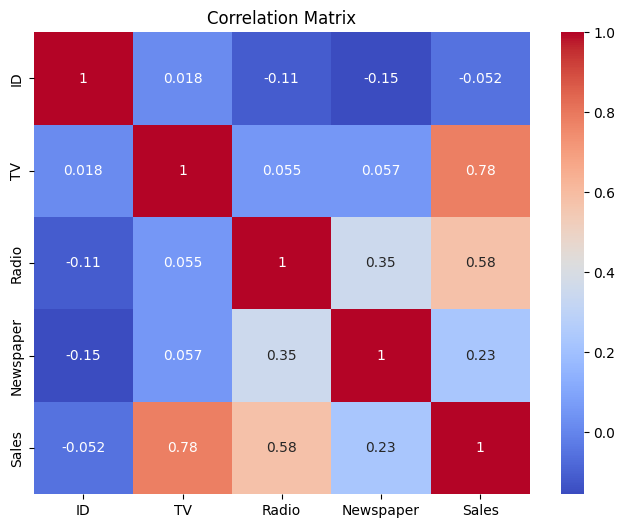

In [53]:
plt.figure(figsize=(8,6))

sns.heatmap(sales_df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

### Observation
- TV advertising has strong correlation with Sales.
- Radio also positively affects Sales.
- Newspaper has comparatively lower impact.

## Pairplot

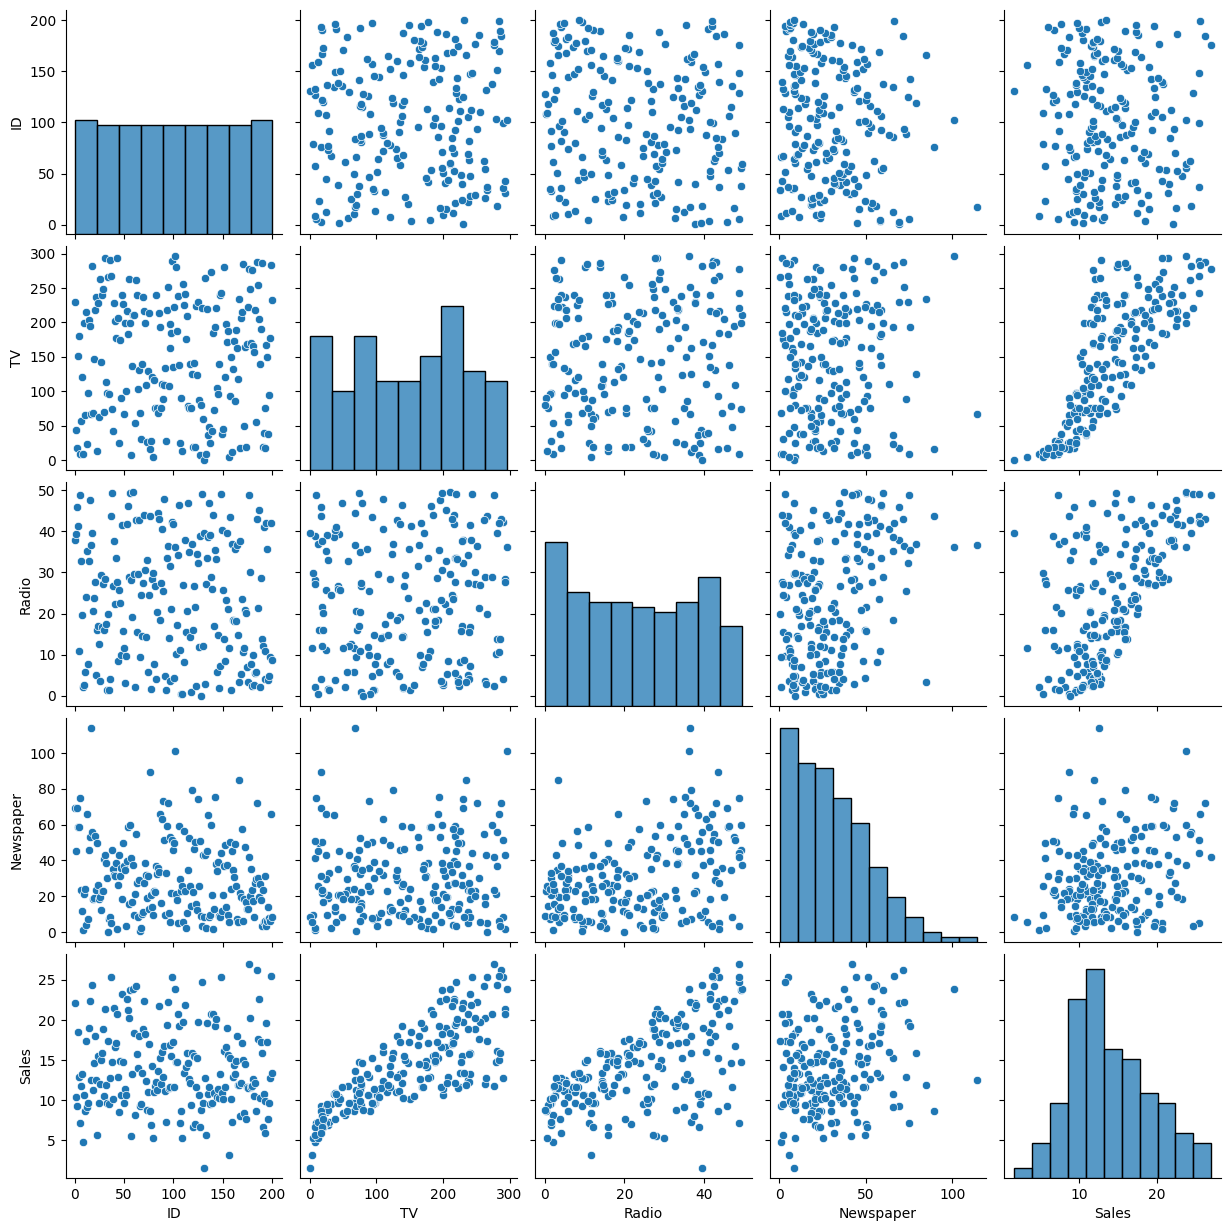

In [32]:
sns.pairplot(sales_df)
plt.show()

## TV Advertising vs Sales

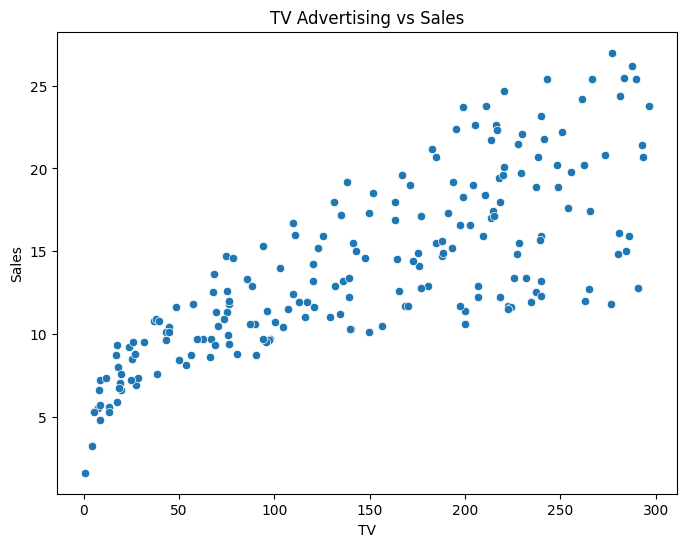

In [33]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='TV', y='Sales', data=sales_df)

plt.title('TV Advertising vs Sales')
plt.show()

### Observation
Sales increase significantly with TV advertising expenditure.

## Radio Advertising vs Sales

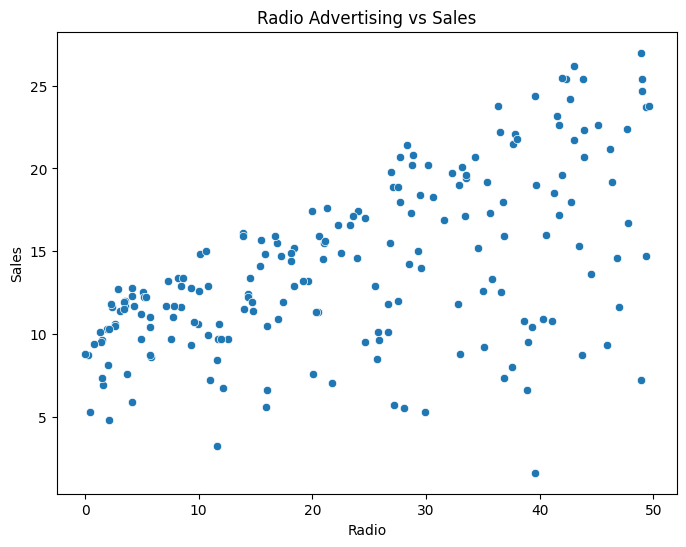

In [34]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='Radio', y='Sales', data=sales_df)

plt.title('Radio Advertising vs Sales')
plt.show()

## Newspaper Advertising vs Sales

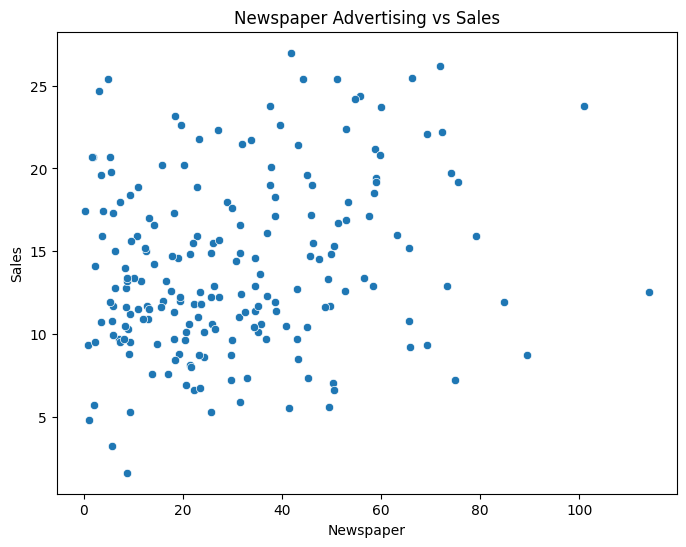

In [35]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='Newspaper', y='Sales', data=sales_df)

plt.title('Newspaper Advertising vs Sales')
plt.show()

## Distribution of Sales

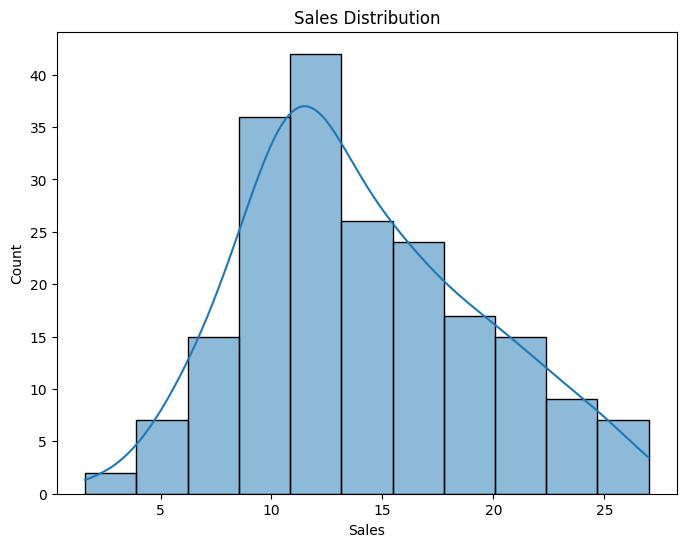

In [36]:
plt.figure(figsize=(8,6))

sns.histplot(sales_df['Sales'], kde=True)

plt.title('Sales Distribution')
plt.show()

# Business Insights

### Key Insights
- TV advertising contributes the highest impact on sales.
- Radio advertising also improves product sales effectively.
- Newspaper advertising contributes less compared to TV and Radio.
- Companies should invest more budget in TV and Radio advertising for higher returns.


# Machine Learning - Sales Prediction

## Prepare Features and Target

In [37]:
X = sales_df[['TV', 'Radio', 'Newspaper']]
y = sales_df['Sales']

## Split Dataset

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train Linear Regression Model

In [39]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## Model Coefficients

In [40]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


### Observation
Higher coefficient indicates stronger impact on Sales prediction.

## Predict Test Data

In [41]:
y_pred = model.predict(X_test)

## Compare Actual and Predicted Values

In [42]:
comparison = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': y_pred
})

comparison.head()

,Actual Sales,Predicted Sales
95,16.9,16.408024
15,22.4,20.889882
30,21.4,21.553843
158,7.3,10.608503
128,24.7,22.112373


## Model Evaluation

In [43]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print('R2 Score:', r2)

Mean Absolute Error: 1.4607567168117603
Mean Squared Error: 3.1740973539761033
Root Mean Squared Error: 1.78159966153345
R2 Score: 0.899438024100912


### Observation
- Lower error values indicate better prediction performance.
- High R2 score indicates strong model accuracy.

## Actual vs Predicted Sales Graph

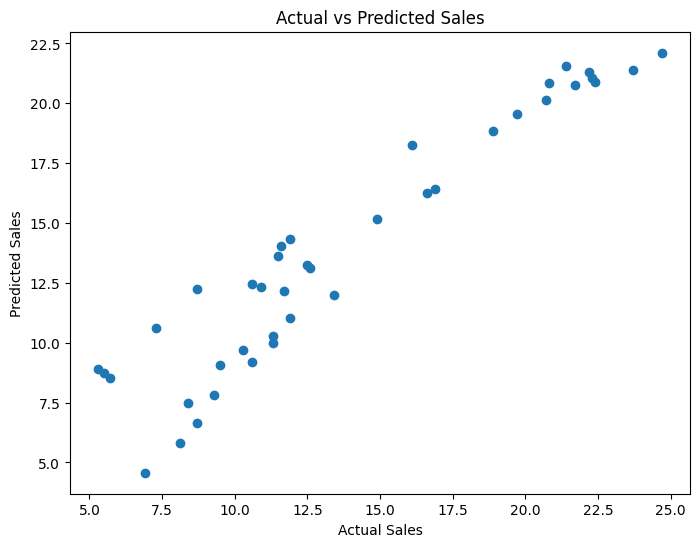

In [44]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')

plt.show()

## Predict New Sales Value

In [45]:
new_data = pd.DataFrame({
    'TV': [230.1],
    'Radio': [37.8],
    'Newspaper': [69.2]
})

predicted_sales = model.predict(new_data)

print('Predicted Sales:', predicted_sales[0])

Predicted Sales: 20.613971470156297


# Conclusion
- Sales data was successfully analyzed.
- EDA and visualization techniques were applied.
- Business insights were identified.
- Linear Regression model successfully predicted Sales.
- TV and Radio advertising showed the strongest impact on Sales.
